# Exploratory Data Analysis : Telco Customer Churn

**Master's Thesis Project**: Agentic AI System for Churn Prevention: Orchestrating ML and LLM Models for Automated Retention Actions

---

## Purpose of this notebook

This EDA is the **foundation** of Chapter 3 (Methodology) of the thesis. Its goals:

1. **Understand** the dataset structure and quality
2. **Identify** the strongest predictors of churn
3. **Detect** segments most at risk -> targets for the LLM agent
4. **Justify** every preprocessing decision for the ML pipeline


---

## Structure

| Section | Content |
|---------|---------|
| 1 | Data loading and overview |
| 2 | Data quality (missing values, duplicates, types) |
| 3 | Target variable analysis |
| 4 | Univariate analysis (numeric + categorical) |
| 5 | Bivariate analysis (features vs churn) |
| 6 | Multivariate analysis (segment identification) |
| 7 | Correlation analysis |
| 8 | Outlier detection |
| 9 | Distribution analysis (skewness, normality) |
| 10 | Statistical tests (Chi², t-test) |
| 11 | PCA visualization |
| 12 | Class imbalance strategies |
| 13 | Preprocessing decisions (→ feeds into model training) |
| 14 | Key insights for the thesis |


---

## Setup

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, normaltest, shapiro

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

---

## 1. Data Loading and Overview

In [2]:
# Loading dataset
df = pd.read_csv('../data/telco_churn.csv')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Shape: (7043, 21)
Rows: 7,043
Columns: 21


In [3]:
# First look at the data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Initial observations

- **7,043 rows × 21 columns**
- `TotalCharges` is stored as `object` (string) instead of numeric, which is suspisious, also with considering that `MonthlyCharges` is `float64`
- `SeniorCitizen` is already encoded as 0/1 (binary integer)
- All other categorical features are stored as strings, so will need encoding

In [5]:
# Descriptive statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


- **`SeniorCitizen`** : mean = 0.16, so only **16% seniors** in our base (since SeniorCitizen is encoded as 0/1 the mean get the proportion of 1s, so of seniors)
- **`MonthlyCharges`** : from **$18** to **$119**, mean ~$65 : wide range of pricing plans

In [6]:
# Descriptive statistics for categorical columns
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


1. **`TotalCharges`** has missing values as top (11)

2. **Class Unbalance** :
   - `Churn = "No"` : 5,174 clients
   - `Churn = "Yes"` : 1,869 clients

3. **Some Dominating Profiles** :
   - 55% clients are under **Month-to-Month** contracts (3,875 clients)
   - 44% use **Fiber optic** as Internet service
   - 34% pay by **Electronic check**
   - 49% **dont have TechSupport**

---

## 2. Data Quality

### 2.1 Missing values

In [7]:
# Standard missing value check
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {missing.sum()}')

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


### 2.2 Hidden missing values

Checking the case of `TotalCharges` saw ealier

In [8]:
# Inspect TotalCharges values
print('Unique value sample:')
print(df['TotalCharges'].unique()[:10])

Unique value sample:
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']


Values are stocked with ''

In [9]:
# Count blank entries
blank_count = (df['TotalCharges'].str.strip() == '').sum()
print(f'\nBlank only entries: {blank_count}')


Blank only entries: 11


In [10]:
# Rows with blank TotalCharges
blank_rows = df[df['TotalCharges'].str.strip() == '']
print(f'\nTenure values for these rows:')
print(blank_rows.value_counts())


Tenure values for these rows:
customerID  gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  MultipleLines     InternetService  OnlineSecurity       OnlineBackup         DeviceProtection     TechSupport          StreamingTV          StreamingMovies      Contract  PaperlessBilling  PaymentMethod              MonthlyCharges  TotalCharges  Churn
1371-DWPAZ  Female  0              Yes      Yes         0       No            No phone service  DSL              Yes                  Yes                  Yes                  Yes                  Yes                  No                   Two year  No                Credit card (automatic)    56.05                         No       1
2520-SGTTA  Female  0              Yes      Yes         0       Yes           No                No               No internet service  No internet service  No internet service  No internet service  No internet service  No internet service  Two year  No                Mailed check               20.00     

What we can see from these rows is that `tenure` = 0 month, so its new clients that haven't been charged yet. So we can direcrly replace these empty values by 0.0, which will keep the info that tose are new customers.

In [11]:
# Convert TotalCharges to numeric, treating blanks as NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'NaN count after conversion: {df["TotalCharges"].isnull().sum()}')

# Impute with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f'NaN count after imputation: {df["TotalCharges"].isnull().sum()}')
print(f'New dtype: {df["TotalCharges"].dtype}')

NaN count after conversion: 11
NaN count after imputation: 0
New dtype: float64


### 2.3 Checking Duplicates

In [12]:
# Check for full-row duplicates
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

# Check for duplicate customer IDs
dup_ids = df['customerID'].duplicated().sum()
print(f'Duplicate customerIDs: {dup_ids}')

Duplicate rows: 0
Duplicate customerIDs: 0


No duplicates, so `customerID` is a true unique identifier.

### 2.4 Dropping the identifier column

In [13]:
df = df.drop(columns=['customerID'])
print(f'Columns remaining: {df.shape[1]}')

Columns remaining: 20


---

## 3. Target Variable Analysis

The target is `Churn` (Yes/No). We need to:
1. Check its distribution (class imbalance saw earlier)
2. Convert it to numeric for modeling

In [14]:
# Converting target to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Churn distribution:')
print(f'  Stayed (0):   {churn_counts[0]:>5,}  ({churn_pct[0]:.2f}%)')
print(f'  Churned (1):  {churn_counts[1]:>5,}  ({churn_pct[1]:.2f}%)')
print(f'\nImbalance ratio: {churn_counts[0]/churn_counts[1]:.2f} : 1')

Churn distribution:
  Stayed (0):   5,174  (73.46%)
  Churned (1):  1,869  (26.54%)

Imbalance ratio: 2.77 : 1


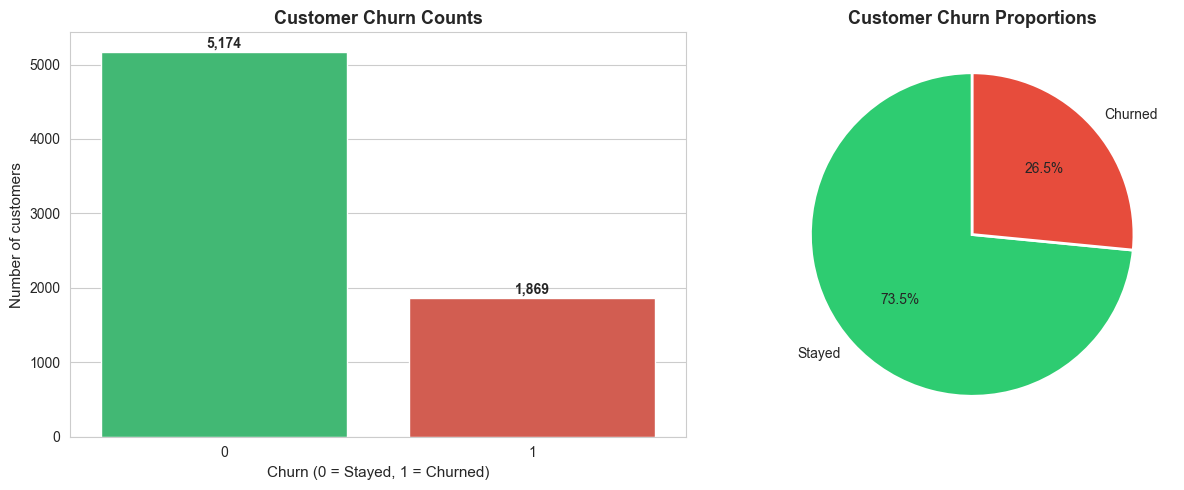

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
sns.countplot(data=df, x='Churn', ax=axes[0],
              palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Customer Churn Counts', fontweight='bold')
axes[0].set_xlabel('Churn (0 = Stayed, 1 = Churned)')
axes[0].set_ylabel('Number of customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values,
            labels=['Stayed', 'Churned'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Customer Churn Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_target_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

### Mild class imbalance

| Class | Count | % |
|-------|-------|---|
| Stayed | 5,174 | 73.5% |
| Churned | 1,869 | 26.5% |

**Imbalance ratio ≈ 2.77 : 1**. Moderate imbalance, but not negligible.

---

## 4. Univariate Analysis

Goal: understand the distribution of each variable in isolation.

### 4.1 Identifying numeric vs categorical features

In [16]:
# Variable types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Churn')  # exclude target

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features ({len(numeric_cols)}):')
print(f'  {numeric_cols}')
print(f'\nCategorical features ({len(categorical_cols)}):')
print(f'  {categorical_cols}')

Numeric features (4):
  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features (15):
  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 4.2 Numeric features

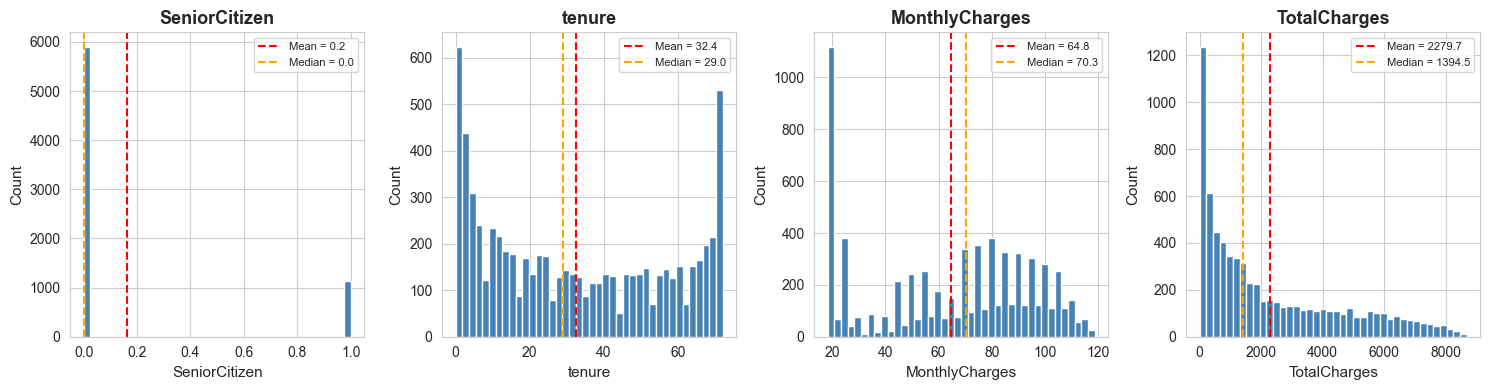

In [17]:
# Histograms
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 4))
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean = {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', label=f'Median = {df[col].median():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_numeric_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

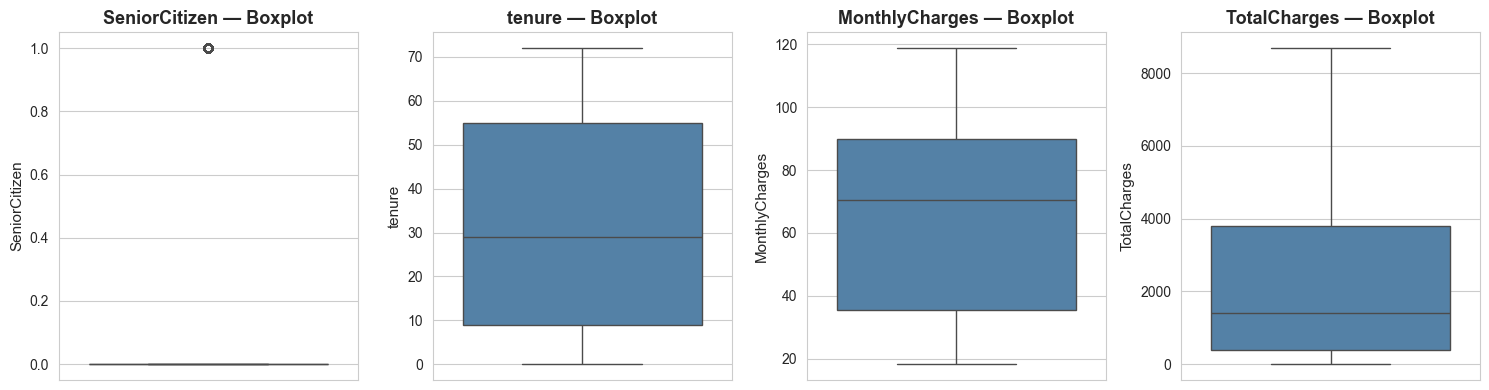

In [18]:
# Boxplots
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 4))
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(f'{col} — Boxplot', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_numeric_boxplots.png', dpi=200, bbox_inches='tight')
plt.show()

- `tenure` shows a bimodal distribution : two customer profiles (short-tenure vs loyal)
- `MonthlyCharges` shows two clusters : basic vs premium plans
- `TotalCharges` is right-skewed (*mechanical: mix of MonthlyCharges and tenure*)
- *Boxplots*: no outliers, all values realistic (max tenure = 72 months)

### 4.3 Categorical features distributions

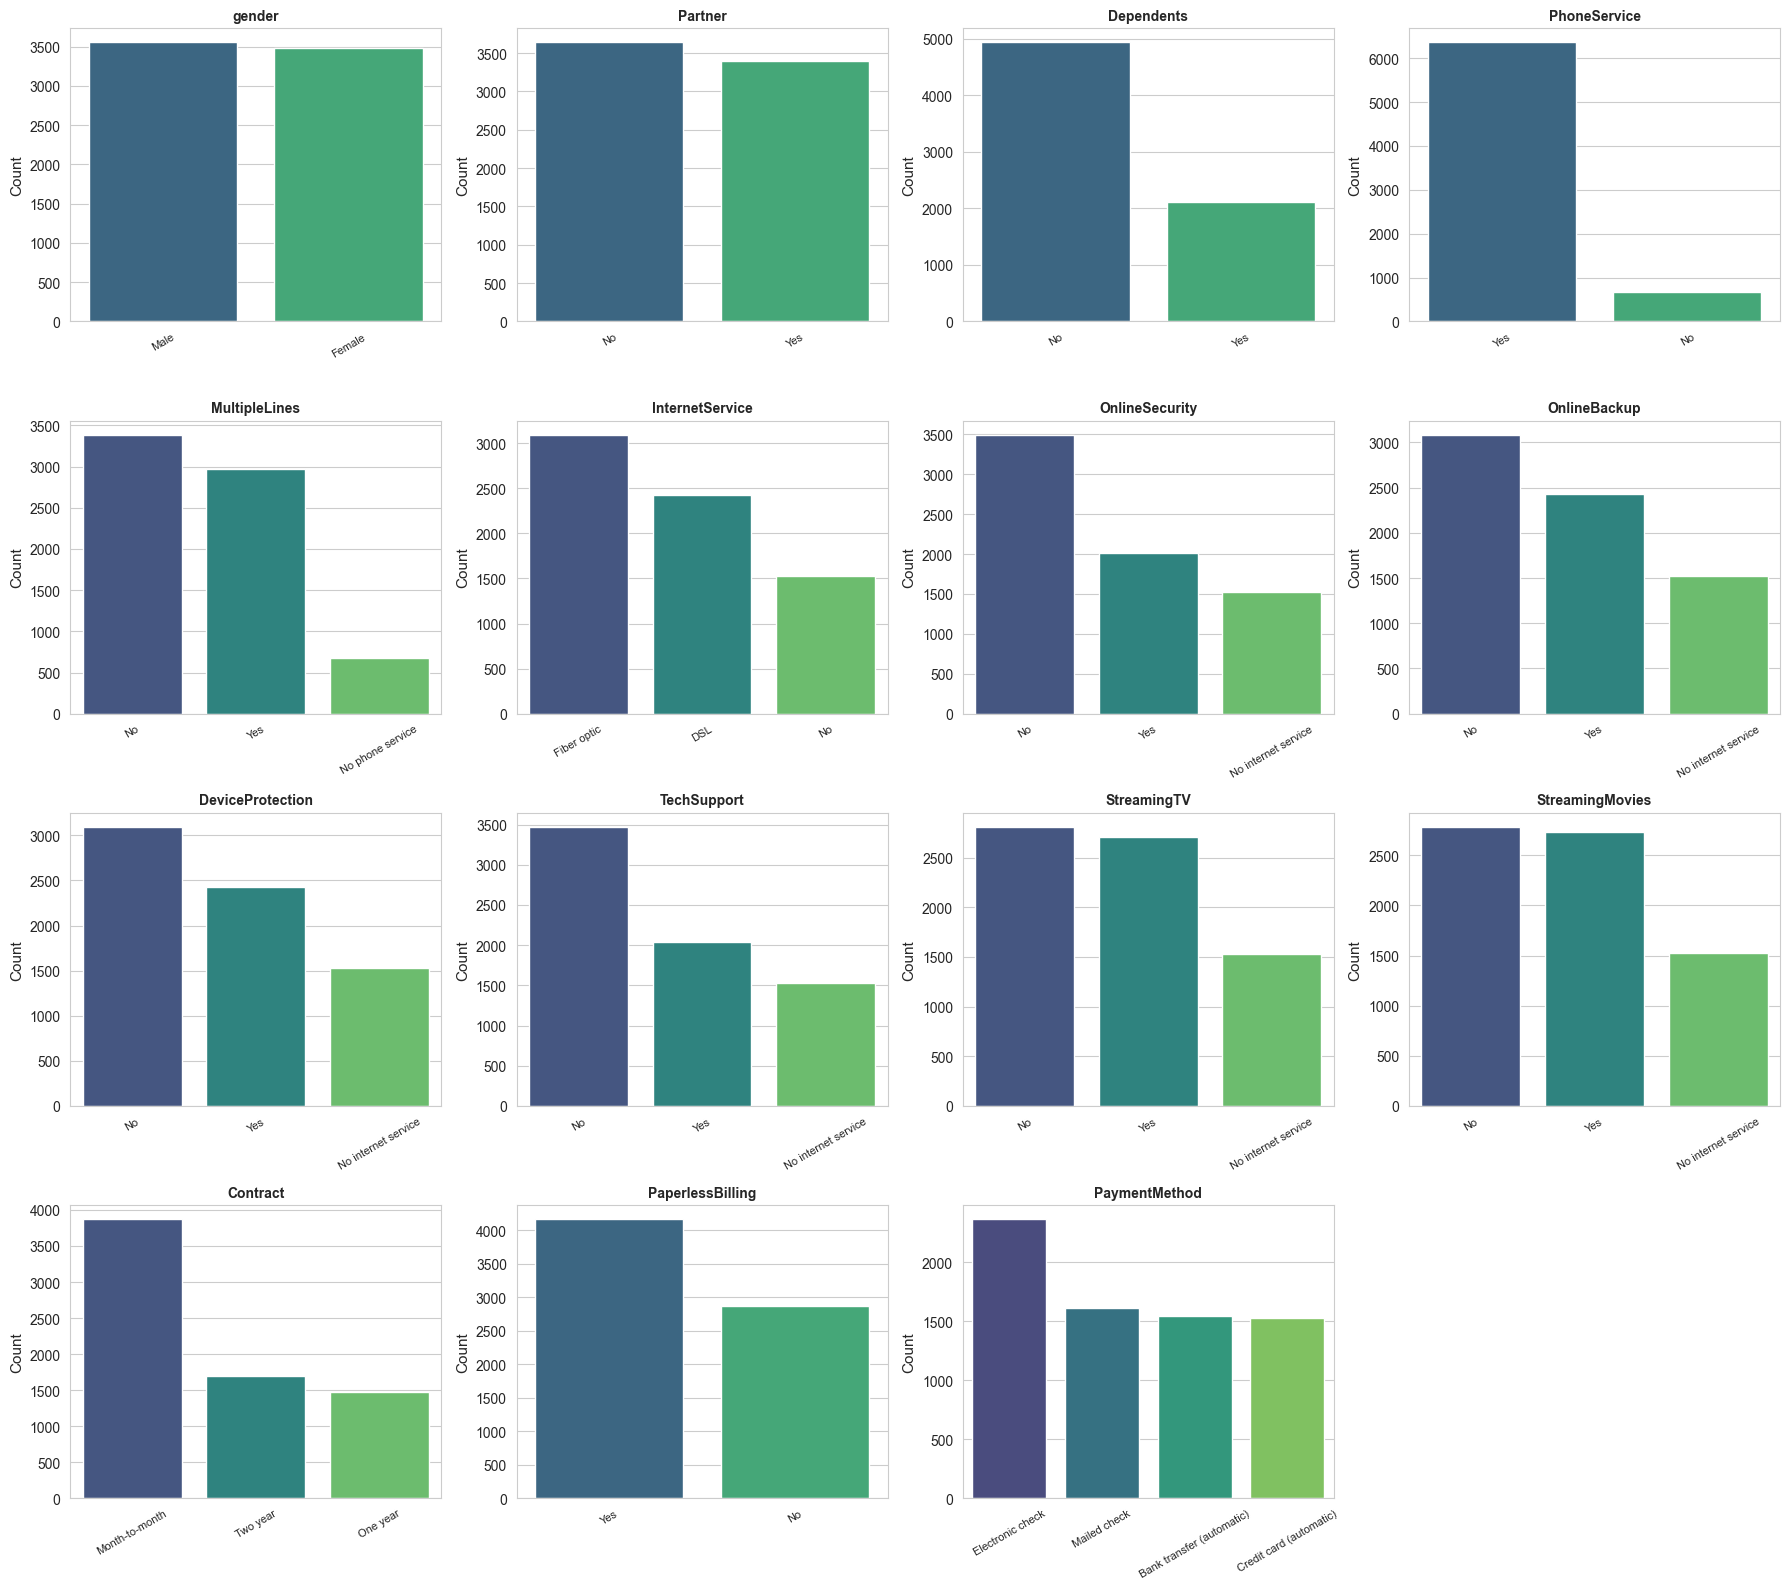

In [19]:
# Categorical features in a grid
n_cols_grid = 4
n_rows_grid = (len(categorical_cols) + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

# Hide unused axes
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_categorical_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

- `gender` is balanced (~50/50)
- 70% of customers have no `dependents`, mostly singles or couples (almost equal) without children
- `PhoneService` is quasi-universal (90%); `internetService` is dominated by Fiber optic (44%)
- Add-on services (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`) show a recurring pattern: ~50% of customers don't subscribe
- `Contract`: 55% are on month-to-month (wich is the most volatile segment within the values of the variable)
- `PaymentMethod`: Electronic check is the most common (34%)

---

## 5. Bivariate Analysis : Features vs Churn

This is **the most important section** for our model: which features actually drive churn?

### 5.1 Numeric features vs Churn

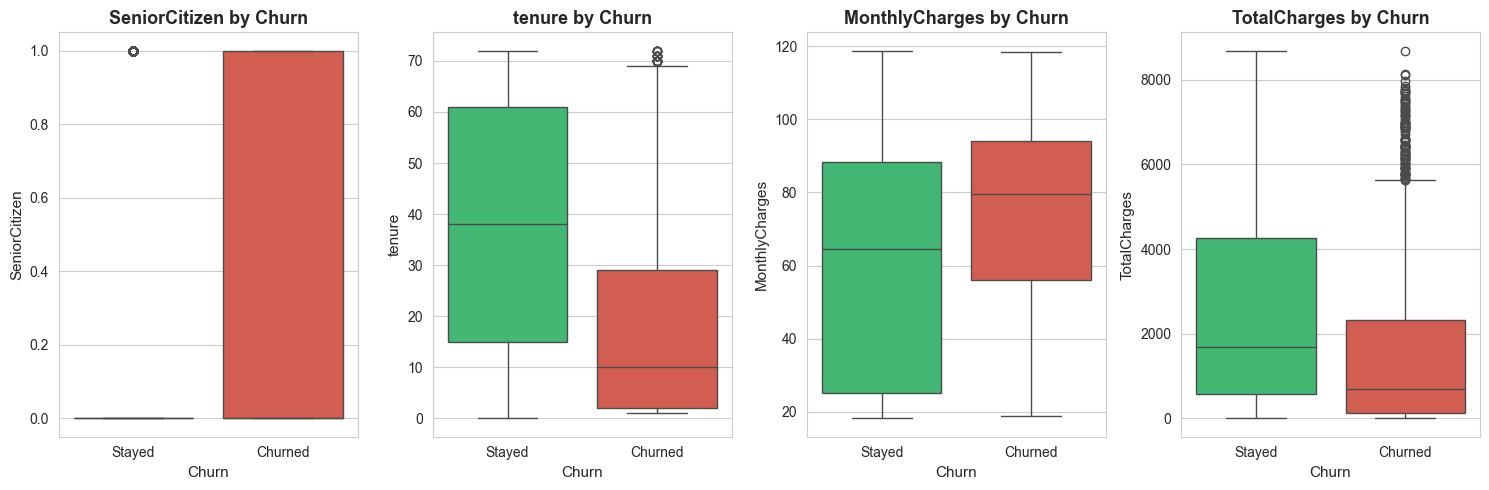

In [20]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax,
                palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{col} by Churn', fontweight='bold')
    ax.set_xticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_numeric_vs_churn.png', dpi=200, bbox_inches='tight')
plt.show()

In [21]:
# Numeric statistics by churn status
print('Mean values by churn status:')
print(df.groupby('Churn')[numeric_cols].mean().round(2))
print('\nMedian values by churn status:')
print(df.groupby('Churn')[numeric_cols].median().round(2))

Mean values by churn status:
       SeniorCitizen  tenure  MonthlyCharges  TotalCharges
Churn                                                     
0               0.13   37.57           61.27       2549.91
1               0.25   17.98           74.44       1531.80

Median values by churn status:
       SeniorCitizen  tenure  MonthlyCharges  TotalCharges
Churn                                                     
0                0.0    38.0           64.43       1679.52
1                0.0    10.0           79.65        703.55


- `Tenure` is the strongest signal: churners have a median tenure of 10 months vs 38 for retained customers (28-month gap)
- `MonthlyCharges`: churners pay more on average ($79.65 vs $64.43 median)
- `SeniorCitizen`: 25% of churners are seniors vs 13% of stayers, while seniors only represent 16% of the base. They are over-represented among churners
- `TotalCharges`: churners show lower totals ($703 vs $1,679 median), but this mostly reflects their shorter tenure (likely multicollinearity with tenure)

### 5.2 Categorical features vs Churn

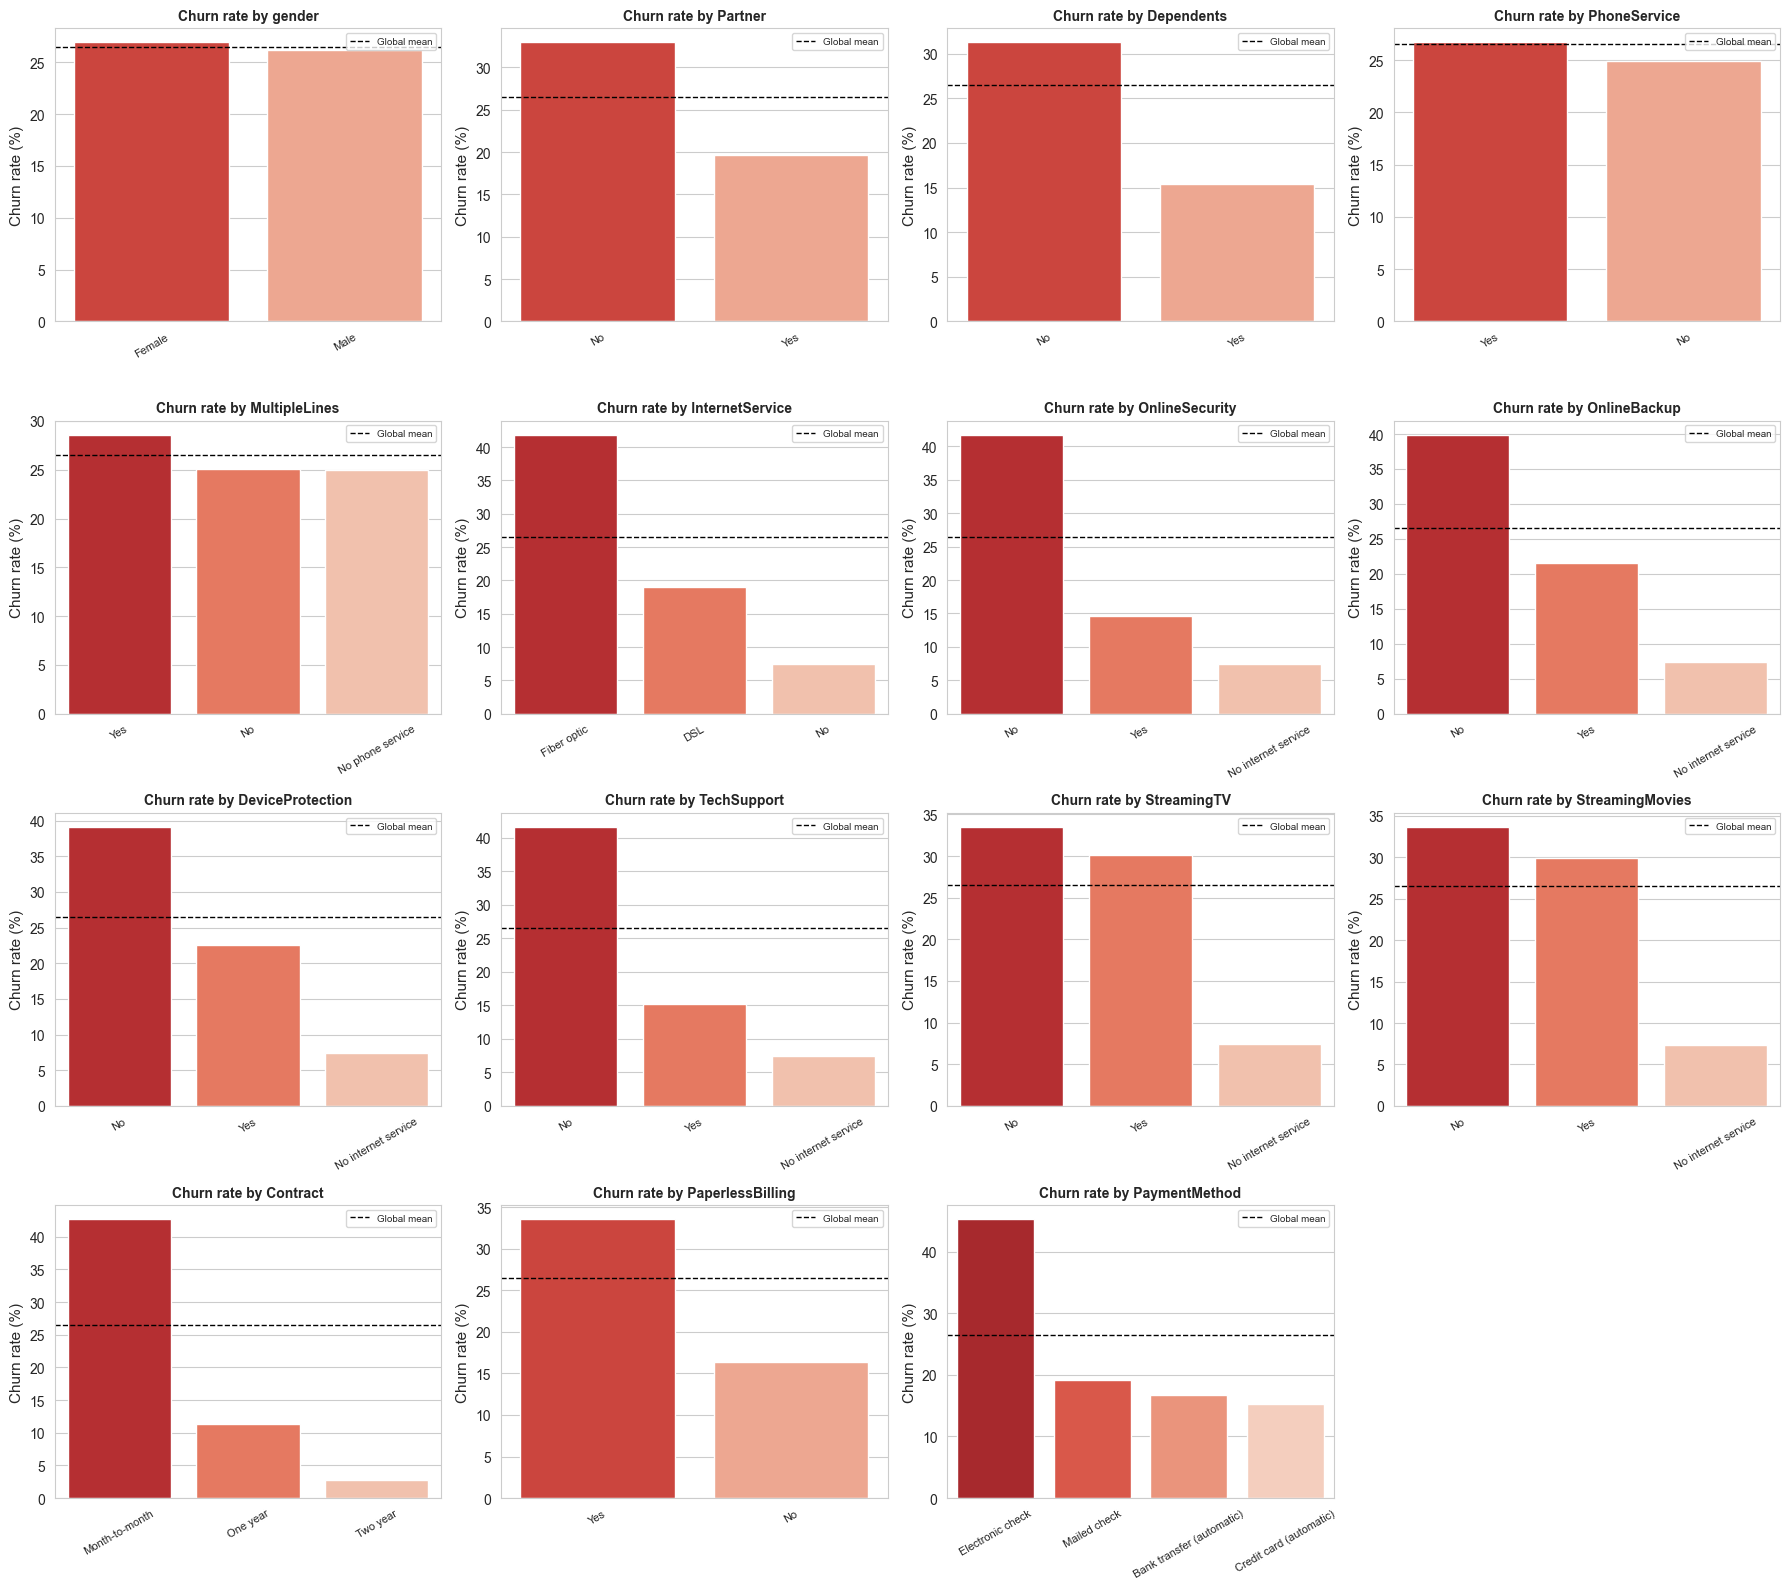

In [22]:
#  Churn rate for each level of each categorical
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_by_cat = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=churn_by_cat.index, y=churn_by_cat.values,
                ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'Churn rate by {col}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].axhline(26.5, color='black', linestyle='--', linewidth=1, label='Global mean')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].legend(fontsize=7)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_categorical_vs_churn.png', dpi=200, bbox_inches='tight')
plt.show()

In [23]:
# Tabular view of churn rate per categorical level
print('Churn rate by categorical feature (top values):\n')
for col in categorical_cols:
    rates = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    print(f'--- {col} ---')
    for level, rate in rates.items():
        print(f'  {level:30s}  {rate*100:5.1f}%')
    print()

Churn rate by categorical feature (top values):

--- gender ---
  Female                           26.9%
  Male                             26.2%

--- Partner ---
  No                               33.0%
  Yes                              19.7%

--- Dependents ---
  No                               31.3%
  Yes                              15.5%

--- PhoneService ---
  Yes                              26.7%
  No                               24.9%

--- MultipleLines ---
  Yes                              28.6%
  No                               25.0%
  No phone service                 24.9%

--- InternetService ---
  Fiber optic                      41.9%
  DSL                              19.0%
  No                                7.4%

--- OnlineSecurity ---
  No                               41.8%
  Yes                              14.6%
  No internet service               7.4%

--- OnlineBackup ---
  No                               39.9%
  Yes                              21.5%
  No

- `Contract` is the dominant predictor: Month-to-month 42.7% vs Two-year 2.8% (15× gap)
- `PaymentMethod`: second strongest predictor. Electronic check 45.3% vs automatic methods ~16% (3× gap)
- `InternetService`: Fiber optic 41.9% vs DSL 19% (friction between expectations and service quality ?)
- Add-on services (`OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtectio`n): "No" -> ~40% churn, "Yes" -> 15-22% churn for each
- Family structure: no Partner / no Dependents → 31-33% churn vs 15-19% with
- `PaperlessBilling` = Yes: 33.6% vs 16.3% (digital savvy customers more nomadic)
- `Gender`: no effect (26.9% F vs 26.2% M)

---

## 6. Multivariate Analysis : Identifying At-Risk Segments

This is where we identify the **specific customer profiles** the LLM agent will target.

In [24]:
# Discretizing numeric variables into meaningful buckets
df_seg = df.copy()

# tenure : 4 customer maturity buckets
df_seg['tenure_bucket'] = pd.cut(
    df_seg['tenure'],
    bins=[-1, 12, 24, 48, 100],
    labels=['New (0-12m)', 'Recent (12-24m)', 'Mature (24-48m)', 'Loyal (48m+)']
)

# MonthlyCharges : 3 price tiers
df_seg['monthly_bucket'] = pd.cut(
    df_seg['MonthlyCharges'],
    bins=[0, 35, 70, 200],
    labels=['Low (<$35)', 'Mid ($35-70)', 'High (>$70)']
)

# SeniorCitizen : readable label
df_seg['senior_label'] = df_seg['SeniorCitizen'].map({0: 'Not senior', 1: 'Senior'})

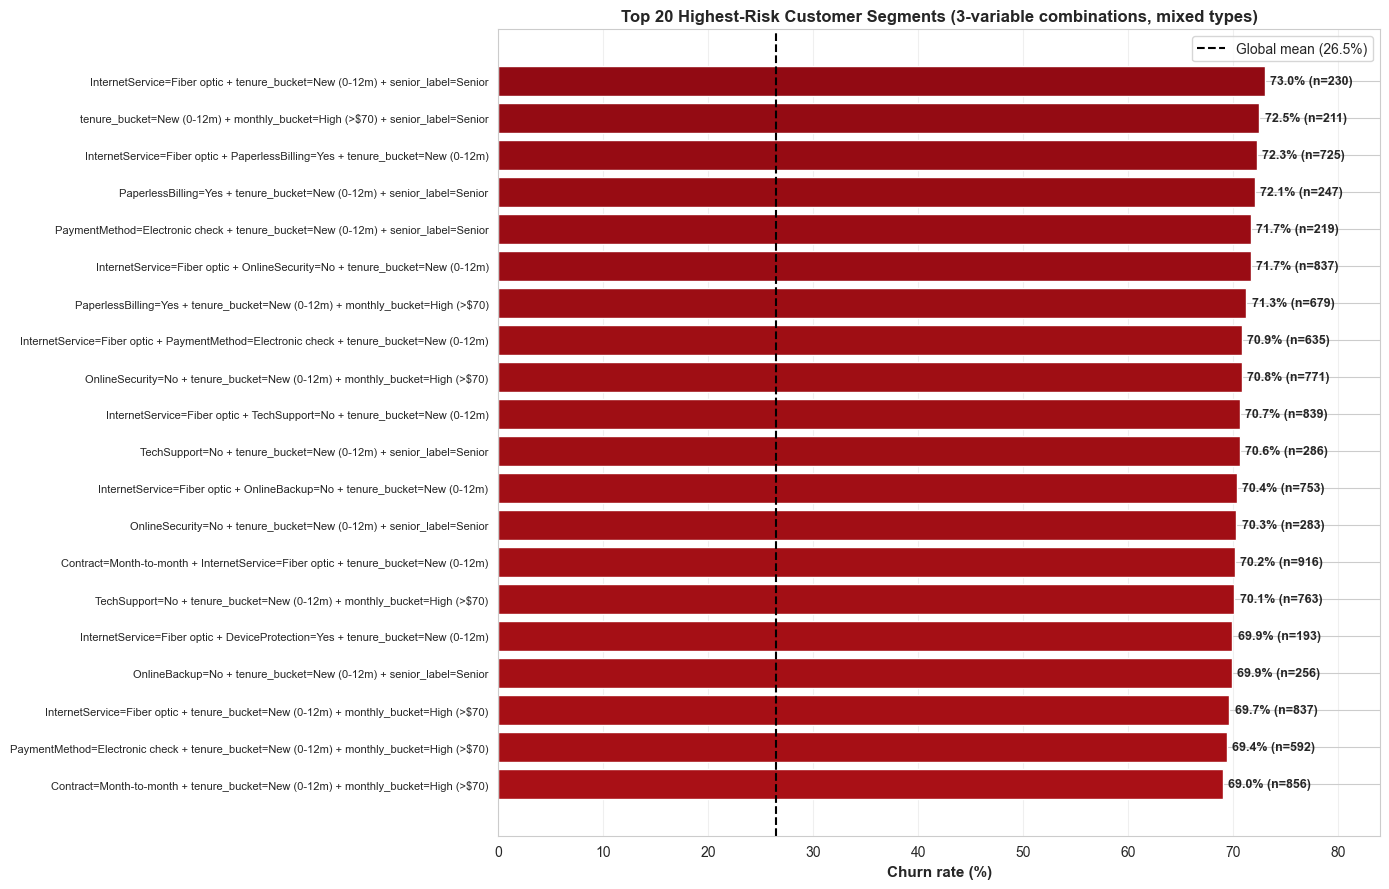


TOP 20 HIGHEST-RISK SEGMENTS (with numeric features)

                                                                                 segment  churn_rate  segment_size
           InternetService=Fiber optic + tenure_bucket=New (0-12m) + senior_label=Senior   73.043478           230
            tenure_bucket=New (0-12m) + monthly_bucket=High (>$70) + senior_label=Senior   72.511848           211
          InternetService=Fiber optic + PaperlessBilling=Yes + tenure_bucket=New (0-12m)   72.275862           725
                  PaperlessBilling=Yes + tenure_bucket=New (0-12m) + senior_label=Senior   72.064777           247
        PaymentMethod=Electronic check + tenure_bucket=New (0-12m) + senior_label=Senior   71.689498           219
             InternetService=Fiber optic + OnlineSecurity=No + tenure_bucket=New (0-12m)   71.684588           837
           PaperlessBilling=Yes + tenure_bucket=New (0-12m) + monthly_bucket=High (>$70)   71.281296           679
InternetService=Fiber opt

In [ ]:
# Risk features (categorical + discretized numeric)
risk_features = [
    'Contract', 'InternetService', 'TechSupport', 'OnlineSecurity',
    'PaymentMethod', 'PaperlessBilling', 'OnlineBackup', 'DeviceProtection',
    'tenure_bucket', 'monthly_bucket', 'senior_label'
]

results = []

# All 3-variable combinations
for combo in combinations(risk_features, 3):
    grouped = df_seg.groupby(list(combo))['Churn'].agg(['mean', 'count'])
    grouped.columns = ['churn_rate', 'segment_size']
    grouped['churn_rate'] = grouped['churn_rate'] * 100
    
    # Filter: segments with at least 100 customers
    grouped = grouped[grouped['segment_size'] >= 100]
    
    if len(grouped) == 0:
        continue
    
    worst = grouped.sort_values('churn_rate', ascending=False).iloc[0]
    
    label = ' + '.join([f'{f}={v}' for f, v in zip(combo, worst.name)])
    
    results.append({
        'segment': label,
        'churn_rate': worst['churn_rate'],
        'segment_size': int(worst['segment_size'])
    })

results_df = pd.DataFrame(results).sort_values('churn_rate', ascending=False).head(20)

# Visualization
fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(range(len(results_df)), results_df['churn_rate'],
               color=plt.cm.Reds(results_df['churn_rate'] / 80))

ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df['segment'], fontsize=8)
ax.invert_yaxis()

ax.set_xlabel('Churn rate (%)', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Highest-Risk Customer Segments (3-variable combinations, mixed types)', 
             fontsize=12, fontweight='bold')

ax.axvline(26.5, color='black', linestyle='--', linewidth=1.5, label='Global mean (26.5%)')
ax.legend(fontsize=10)

for i, (rate, size) in enumerate(zip(results_df['churn_rate'], results_df['segment_size'])):
    ax.text(rate + 0.5, i, f'{rate:.1f}% (n={size})', 
            va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, max(results_df['churn_rate']) * 1.15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_top20_risk_segments.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nTOP 20 HIGHEST-RISK SEGMENTS (with numeric features)\n')
print(results_df.to_string(index=False))

A systematic search across 165 combinations of 3 variables (8 categorical + 3 discretized numeric, filtered to segments with at least 100 customers) reveals:

- **`tenure_bucket = New (0-12m)` appears in ALL 20 top segments** : the *dominant* risk factor
- **#1 segment**: Fiber optic + New + Senior → **73.0% churn** (230 customers)
- All top 20 segments exceed 69% churn, up to 73% (vs 26.5% globally, so 2.6 to 2.75× higher than the global average)
- Frequency in top 20: New (20/20), Fiber optic (9/20), Senior (7/20), High charges (7/20)

---

## 7. Correlation Analysis

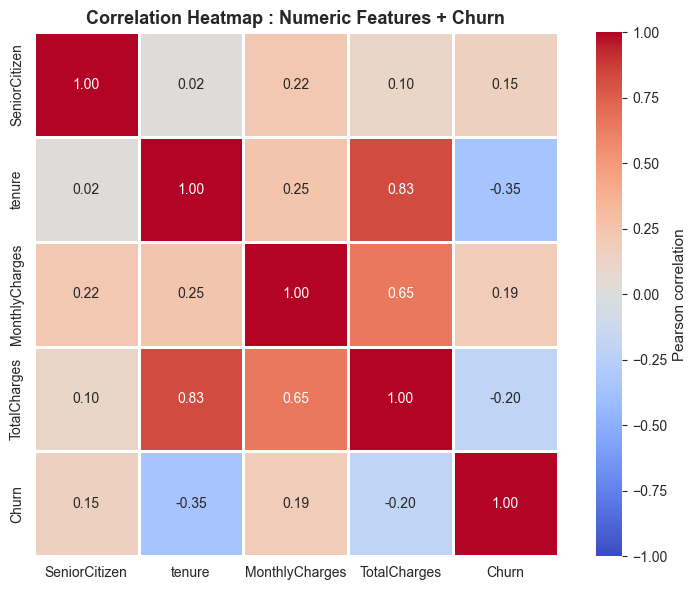

In [26]:
# Correlation matrix on numeric features (including Churn)
corr_cols = numeric_cols + ['Churn']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=1, linecolor='white',
            cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation Heatmap : Numeric Features + Churn', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

- **Multicollinearity detected**: `tenure` <-> `TotalCharges` (r = 0.83), `MonthlyCharges` <-> `TotalCharges` (r = 0.65) ; mechanically expected since `TotalCharges ≈ combination of MonthlyCharges & tenure`
- **Linear correlations with Churn are modest** (all < 0.40):
  - `tenure` <-> Churn: -0.35 (lower tenure gives more churn)
  - `MonthlyCharges` <-> Churn: +0.19 (higher charges bring so more churn)
  - `TotalCharges` <-> Churn: -0.20 (mechanically tied to tenure)
  - `SeniorCitizen` <-> Churn: +0.15
- `SeniorCitizen` and `tenure` are independent (r = 0.02) : seniors are not systematically newer or older customers

---

## 8. Outlier Detection

We use two complementary methods:
- **IQR method**: any value beyond `Q1 - 1.5 × IQR` or `Q3 + 1.5 × IQR`
- **Z-score method**: any value > 3 standard deviations from the mean

In [27]:
def detect_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((series < low) | (series > high)).sum(), low, high

def detect_outliers_zscore(series, thresh=3):
    z = np.abs((series - series.mean()) / series.std())
    return (z > thresh).sum()

print(f'{"Feature":<20s} {"IQR outliers":<15s} {"Z>3 outliers":<15s} {"Range (IQR)":<25s}')
print('-' * 80)
for col in numeric_cols:
    iqr_count, low, high = detect_outliers_iqr(df[col])
    z_count = detect_outliers_zscore(df[col])
    print(f'{col:<20s} {iqr_count:<15d} {z_count:<15d} [{low:>8.1f}, {high:>8.1f}]')

Feature              IQR outliers    Z>3 outliers    Range (IQR)              
--------------------------------------------------------------------------------
SeniorCitizen        1142            0               [     0.0,      0.0]
tenure               0               0               [   -60.0,    124.0]
MonthlyCharges       0               0               [   -46.0,    171.4]
TotalCharges         0               0               [ -4683.5,   8868.7]


### Outlier detection

Confirms the visual finding from Section 4.2:
- IQR method: 0 outliers across all numeric features (apparent outliers in SeniorCitizen are not meaningful since it is a binary variable, so it is the number of 1s)
- Z-score method (>3σ): 0 outliers
- All values realistic in a telecom context

---

## 9. Distribution Analysis : Skewness & Normality

In [28]:
# Check skewness
print(f'{"Feature":<20s} {"Skewness":>10s} {"Interpretation":<30s}')
print('-' * 65)
for col in numeric_cols:
    skew = df[col].skew()
    if abs(skew) < 0.5:
        interp = 'Approximately symmetric'
    elif abs(skew) < 1:
        interp = 'Moderately skewed'
    else:
        interp = 'Highly skewed'
    print(f'{col:<20s} {skew:>10.3f}  {interp}')

Feature                Skewness Interpretation                
-----------------------------------------------------------------
SeniorCitizen             1.834  Highly skewed
tenure                    0.240  Approximately symmetric
MonthlyCharges           -0.221  Approximately symmetric
TotalCharges              0.963  Moderately skewed


In [29]:
# Normality test (D'Agostino's K²)
print('Normality test (D\'Agostino K²):')
print('Null hypothesis: data is normally distributed (reject if p < 0.05)\n')

for col in numeric_cols:
    stat, p = normaltest(df[col])
    decision = 'Not normal' if p < 0.05 else 'Could be normal'
    print(f'  {col:<20s} statistic={stat:>10.2f}  p-value={p:.4e}  {decision}')

Normality test (D'Agostino K²):
Null hypothesis: data is normally distributed (reject if p < 0.05)

  SeniorCitizen        statistic=   2089.74  p-value=0.0000e+00  Not normal
  tenure               statistic=  76258.51  p-value=0.0000e+00  Not normal
  MonthlyCharges       statistic=  11419.53  p-value=0.0000e+00  Not normal
  TotalCharges         statistic=    808.60  p-value=2.6049e-176  Not normal


- `TotalCharges` is moderately right-skewed (0.96), confirming the histogram observation
- `SeniorCitizen` skew = 1.83 : artifact of binary distribution
- `tenure` and `MonthlyCharges` are approximately symmetric (skew ≈ 0)
- All numeric features **fail the normality test** (D'Agostino K², p ≈ 0), indicating non-normal distributions

Tree-based models do not assume normality. For a logistic regression baseline, a `log1p` transform on `TotalCharges` could improve linear separability.

---

## 10. Statistical Tests

### 10.1 T-test : numeric features vs Churn

> H₀: the mean of the numeric feature is the same for churners and non-churners.

In [30]:
print(f'{"Feature":<20s} {"t-statistic":>12s} {"p-value":>15s} {"Significant?":<15s}')
print('-' * 70)
for col in numeric_cols:
    churn_yes = df[df['Churn'] == 1][col]
    churn_no  = df[df['Churn'] == 0][col]
    t_stat, p_val = ttest_ind(churn_yes, churn_no, equal_var=False)
    sig = 'Yes' if p_val < 0.05 else 'No'
    print(f'{col:<20s} {t_stat:>12.3f} {p_val:>15.4e}  {sig}')

Feature               t-statistic         p-value Significant?   
----------------------------------------------------------------------
SeniorCitizen              11.344      3.5876e-29  Yes
tenure                    -34.824     1.1955e-232  Yes
MonthlyCharges             18.408      8.5924e-73  Yes
TotalCharges              -18.707      5.9026e-75  Yes


### 10.2 Chi-squared test : categorical features vs Churn

> H₀: the categorical feature and Churn are independent.

In [31]:
results = []
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2, p_val, dof, _ = chi2_contingency(contingency)
    results.append({
        'Feature': col,
        'Chi² statistic': round(chi2, 2),
        'p-value': p_val,
        'Significant (α=0.05)': 'yes' if p_val < 0.05 else 'no'
    })

results_df = pd.DataFrame(results).sort_values('Chi² statistic', ascending=False)
print(results_df.to_string(index=False))

         Feature  Chi² statistic       p-value Significant (α=0.05)
        Contract         1184.60 5.863038e-258                  yes
  OnlineSecurity          850.00 2.661150e-185                  yes
     TechSupport          828.20 1.443084e-180                  yes
 InternetService          732.31 9.571788e-160                  yes
   PaymentMethod          648.14 3.682355e-140                  yes
    OnlineBackup          601.81 2.079759e-131                  yes
DeviceProtection          558.42 5.505219e-122                  yes
 StreamingMovies          375.66  2.667757e-82                  yes
     StreamingTV          374.20  5.528994e-82                  yes
PaperlessBilling          258.28  4.073355e-58                  yes
      Dependents          189.13  4.924922e-43                  yes
         Partner          158.73  2.139911e-36                  yes
   MultipleLines           11.33  3.464383e-03                  yes
    PhoneService            0.92  3.387825e-01  

**T-test (numeric features vs Churn)**: all four numeric features show highly significant differences between churners and non-churners (p < 10⁻²⁹). `tenure` has the largest t-statistic (34.8), confirming it as the strongest numeric predictor.

**Chi² test (categorical features vs Churn)**:
- 13 of 15 features are highly significant (p < 0.001)
- Top predictors confirmed: `Contract` (Chi² = 1184), `OnlineSecurity` (850), `TechSupport`
  (828), `InternetService` (732), `PaymentMethod` (648)
- **Two features fail the test and will be dropped from the model:**
  - `gender` (p = 0.49)
  - `PhoneService` (p = 0.34)

---

## 11. PCA Visualization

PCA helps us see whether churners and non-churners can be separated in a low-dimensional space.

Variance explained:
  PC1: 33.2%
  PC2: 12.0%
  Total: 45.2%


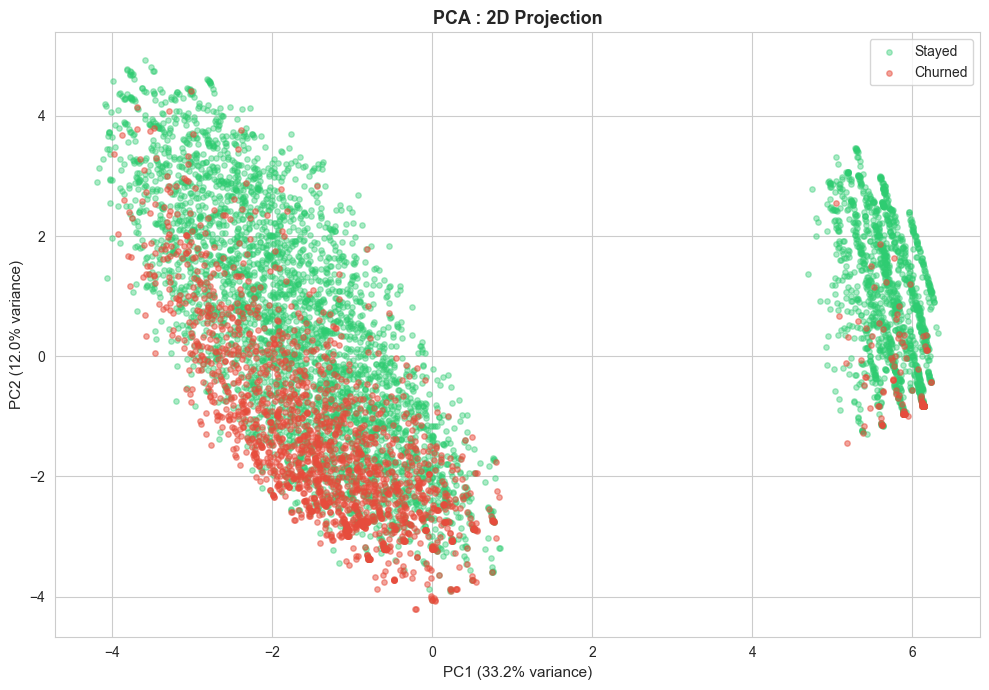

In [32]:
# Encode categoricals for PCA (one-hot)
df_pca = pd.get_dummies(df.drop(columns=['Churn']), drop_first=True)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# PCA : 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Variance explained
print(f'Variance explained:')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Total: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[df['Churn']==0, 0], X_pca[df['Churn']==0, 1],
            c='#2ecc71', alpha=0.4, s=15, label='Stayed')
plt.scatter(X_pca[df['Churn']==1, 0], X_pca[df['Churn']==1, 1],
            c='#e74c3c', alpha=0.5, s=15, label='Churned')
plt.title('PCA : 2D Projection', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/9_pca_visualization.png', dpi=200, bbox_inches='tight')
plt.show()

PC1 + PC2 capture **45% of total variance**. The 2D projection reveals:

1. **Two visible clusters along PC1**: a small group on the right (mostly Stayed, likely the "No internet service" customers, recall 7.4% churn rate from Section 5) and a larger main cloud on the left.
2. **Class overlap within the main cloud**: Stayed and Churned points are mixed, with only a mild PC2 trend (more red toward the bottom).

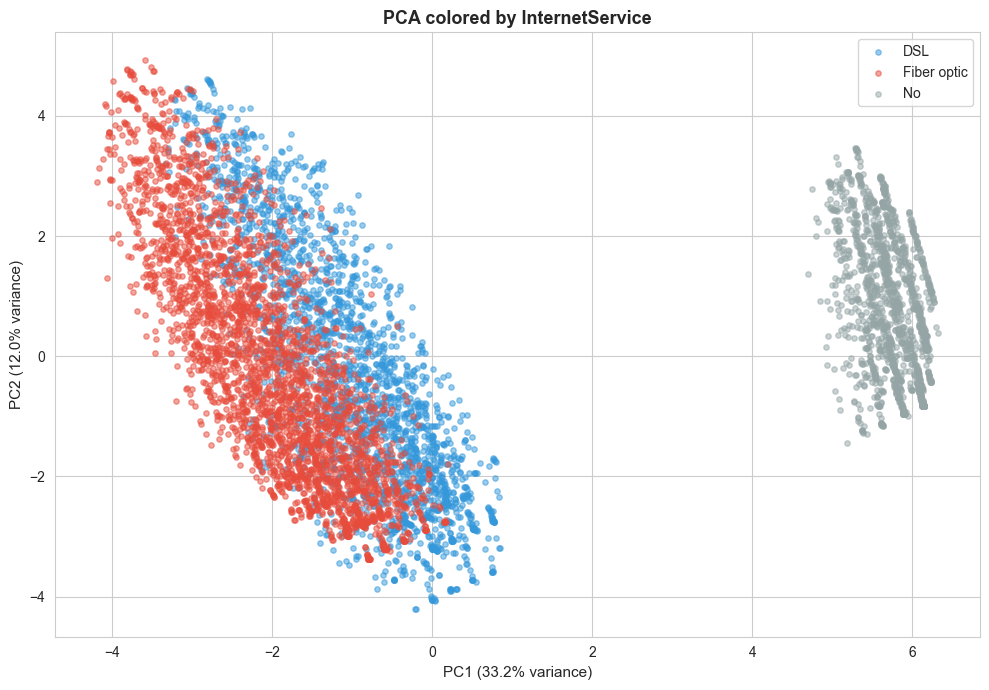

In [33]:
# Coloring the points by 'InternetService' instead of 'Churn'
plt.figure(figsize=(10, 7))

colors = {'DSL': '#3498db', 'Fiber optic': '#e74c3c', 'No': '#95a5a6'}

for service, color in colors.items():
    mask = df['InternetService'] == service
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, alpha=0.5, s=15, label=service)

plt.title('PCA colored by InternetService', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/9b_pca_visualization_by_internet_service.png', dpi=200, bbox_inches='tight')
plt.show()

To verify the structural hypothesis from the previous figure, we re-projected the same PCA coordinates colored by `InternetService`. The result confirms:
1. The **right cluster is entirely "No internet service"** customers, justifying their isolation. They lack all internet add-on services, producing a very different feature configuration from internet subscribers.
2. Within the **main left cloud**, **PC2 partially separates DSL (top) from Fiber optic (bottom)**, aligning with the churn patterns observed in Section 5 (Fiber 41.9% vs DSL 19.0%).

This confirms that PCA captures meaningful business structure: the customer base is naturally split between internet and non-internet subscribers, with internet customers further differentiated by service tier.

In [34]:
# How each feature contributes to PC1 and PC2
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df_pca.columns
)

# Top 10 features contributing to PC1 (positive / negative)
print('Top 10 features pushing RIGHT on PC1 (right cluster):')
print(loadings['PC1'].sort_values(ascending=False).head(10))

print('\nTop 10 features pushing LEFT on PC1 (main left cloud):')
print(loadings['PC1'].sort_values().head(10))

Top 10 features pushing RIGHT on PC1 (right cluster):
DeviceProtection_No internet service    0.302314
TechSupport_No internet service         0.302314
StreamingTV_No internet service         0.302314
StreamingMovies_No internet service     0.302314
OnlineBackup_No internet service        0.302314
OnlineSecurity_No internet service      0.302314
InternetService_No                      0.302314
PaymentMethod_Mailed check              0.132448
Dependents_Yes                          0.041261
Contract_Two year                       0.037101
Name: PC1, dtype: float64

Top 10 features pushing LEFT on PC1 (main left cloud):
MonthlyCharges                -0.282448
TotalCharges                  -0.184903
StreamingMovies_Yes           -0.180038
InternetService_Fiber optic   -0.179507
StreamingTV_Yes               -0.179047
DeviceProtection_Yes          -0.159526
OnlineBackup_Yes              -0.153179
TechSupport_Yes               -0.129460
OnlineSecurity_Yes            -0.121785
PaperlessBilli

The PC1 loadings confirm the structural split observed in the projection:
- **Right cluster (high PC1)** is dominated by all "No internet service" markers. These features are mechanically correlated (a customer without internet cannot have OnlineSecurity, TechSupport, etc.), so they collapse into a single dimension representing the **"No internet" condition**.
- **Left cloud (low PC1)** is driven by `MonthlyCharges` (-0.28), `TotalCharges` (-0.18), premium internet (`Fiber optic`, -0.18) and engagement signals (StreamingTV/Movies,add-on services, PaperlessBilling).

PC1 therefore captures the **single biggest source of variance in the data (33.2%)**: the divide between internet and non-internet subscribers, with internet customers further differentiated by their level of engagement and service consumption.

In [35]:
# Top 10 features contributing to PC2 (positive / negative)
print('Top 10 features pushing UP on PC2 (top of cloud):')
print(loadings['PC2'].sort_values(ascending=False).head(10))

print('\nTop 10 features pushing DOWN on PC2 (bottom of cloud):')
print(loadings['PC2'].sort_values().head(10))

Top 10 features pushing UP on PC2 (top of cloud):
tenure                                   0.437960
TotalCharges                             0.376464
Contract_Two year                        0.352777
Partner_Yes                              0.261468
DeviceProtection_Yes                     0.193984
TechSupport_Yes                          0.191928
Dependents_Yes                           0.185836
MultipleLines_Yes                        0.184540
PaymentMethod_Credit card (automatic)    0.183383
OnlineSecurity_Yes                       0.173445
Name: PC2, dtype: float64

Top 10 features pushing DOWN on PC2 (bottom of cloud):
PaymentMethod_Electronic check   -0.214026
MultipleLines_No phone service   -0.115989
PaperlessBilling_Yes             -0.064706
SeniorCitizen                    -0.059611
PaymentMethod_Mailed check       -0.054495
InternetService_Fiber optic      -0.040472
gender_Male                      -0.002187
MonthlyCharges                    0.083470
Contract_One year       

The loadings of PC2 reveal that this axis captures a meaningful business dimension:
- **Top of cloud (high PC2)** : protective features dominate: long `tenure` (+0.44),`Contract_Two year` (+0.35), `Partner_Yes` (+0.26), and add-on services (`DeviceProtection`, `TechSupport` & `OnlineSecurity` all positive).
- **Bottom of cloud (low PC2)** : risk features dominate: `PaymentMethod_Electronic check` (-0.21), `SeniorCitizen` (-0.06), `PaperlessBilling` (-0.06), `InternetService_Fiber optic` (-0.04).

PC2 therefore represents a **continuous customer fragility score** that aggregates the discrete risk patterns identified across the previous sections (bivariate analysis in Section 5, multivariate segments in Section 6, statistical tests in Section 10).

---

## 12. Class Imbalance Handling Strategies

The 73/27 imbalance (ratio ≈ 2.77:1) is moderate. 2 approaches will be considered during model training:

1. **`class_weight='balanced'`**, built-in option in most libraries (sklearn, lightgbm,xgboost). Reweights the loss function without modifying the data. Simple and effective.
2. **SMOTE (Synthetic Minority Oversampling)** : generates synthetic minority samples by interpolation. Applied **only on the training set**, after the train/test split.

**Plan for training**: start with `class_weight='balanced'` for all models. Try SMOTE if minority recall is too low. 

We will also avoid accuracy as primary metric and use F1, ROC-AUC, precision/recall instead.

---

## 13. Preprocessing Decisions  Summary Table

This table consolidates every preprocessing decision made throughout the EDA. It serves as the specification for the preprocessing pipeline implemented in the next step.

In [36]:
decisions = pd.DataFrame([
    {'Step': '1. Drop identifier',
     'Action': 'Drop customerID',
     'Reason': 'Unique identifier, not predictive (Section 2.4)'},

    {'Step': '2. Hidden missing values',
     'Action': 'Convert TotalCharges to numeric, impute 11 NaNs with 0',
     'Reason': 'All NaNs correspond to tenure=0 (new customers)'},

    {'Step': '3. Target encoding',
     'Action': 'Map Churn Yes/No : 1/0',
     'Reason': 'Required for ML models'},

    {'Step': '4. Drop non-significant features',
     'Action': 'Drop gender (Chi² p = 0.49) and PhoneService (Chi² p = 0.34)',
     'Reason': 'Independent from Churn'},

    {'Step': '5. Feature engineering',
     'Action': 'Create avg_monthly_charge = TotalCharges / (tenure + 1) and drop TotalCharges',
     'Reason': 'Mitigates multicollinearity (r=0.83 with tenure)'},

    {'Step': '6. Categorical encoding',
    'Action': 'One-hot encoding for nominal categoricals, ordinal encoding for Contract',
    'Reason': 'Contract has natural order (M2M < 1yr < 2yr), others are nominal'},

    {'Step': '7. Stratified train/validation/test split',
     'Action': '60/20/20 split stratified by Churn',
     'Reason': 'Preserve class balance in all sets'},

    {'Step': '8. Class imbalance',
     'Action': "class_weight='balanced' as default; SMOTE if minority recall is low",
     'Reason': '2.77:1 ratio, moderate imbalance'},

])

print(decisions.to_string(index=False))

                                     Step                                                                        Action                                                           Reason
                       1. Drop identifier                                                               Drop customerID                  Unique identifier, not predictive (Section 2.4)
                 2. Hidden missing values                        Convert TotalCharges to numeric, impute 11 NaNs with 0                  All NaNs correspond to tenure=0 (new customers)
                       3. Target encoding                                                        Map Churn Yes/No : 1/0                                           Required for ML models
         4. Drop non-significant features                  Drop gender (Chi² p = 0.49) and PhoneService (Chi² p = 0.34)                                           Independent from Churn
                   5. Feature engineering Create avg_monthly_charge = Total

---

## 14. Key Insights for the Thesis

### Top 10 takeaways

1. **Hidden missing values discovered** (Section 2): 11 customers had `TotalCharges` stored as blank strings, all corresponding to brand-new accounts (tenure = 0). Imputed to 0.

2. **Moderate class imbalance** (Section 3): 73% / 27%, ratio ≈ 2.77:1. Primary metrics: F1, ROC-AUC, precision/recall ; not accuracy.

3. **Strongest churn predictors** confirmed by both visualization and statistical tests (Sections 5, 10): `Contract`, `tenure`, `InternetService`, `PaymentMethod`, add-on services (`OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection`).

4. **Two features dropped** (Section 10): `gender` and `PhoneService` show no significant association with churn.

5. **Highest-risk segment** (Section 6): Fiber optic + tenure < 12 months + Senior -> 73% churn rate (230 customers). All top-20 segments include `tenure_bucket = New (0-12m)`.

6. **Tenure is bimodal** (Section 4): customers either leave early or stay long-term. The first 12 months are critical for retention.

7. **Multicollinearity** between `tenure` and `TotalCharges`. Engineered feature `avg_monthly_charge` mitigates this for the logistic regression baseline.

8. **Add-on services protect against churn** (Sections 5, 6): customers without `OnlineSecurity`, `TechSupport`, etc., churn ~3× more than those with. These services act as stickiness factors and represent a key action lever for the LLM agent.
Also prioritize **new subscribers** (tenure < 12 months), especially those combining premium service (Fiber, high charges) and senior status.

9. **Electronic check is the riskiest payment method** (Section 5): 45.3% churn vs ~16% for automatic methods. Migration to autopay is a clear retention opportunity.

10. **PCA reveals interpretable structure** (Section 11): PC1 captures the "Internet vs No Internet" divide; PC2 captures a continuous "customer fragility" axis. Class overlap in 2D indicates that simple 2D linear separation is insufficient. However, this visualization has limitations:
- It only shows 2 dimensions of a higher-dimensional space
- Important discriminative patterns may exist in the remaining 55% of variance
- PCA is unsupervised and doesn't optimize for class separation

    Given this uncertainty, we will evaluate both linear models (Logistic Regression) and non-linear models (tree-based ensembles) to determine which approach best captures the churn signal in the full feature space."

---

### Output artifacts

| File | Used in thesis section |
|------|----------------------|
| `01_target_distribution.png` | 3.3 Target analysis |
| `02_numeric_distributions.png` | 3.3 Univariate analysis |
| `03_numeric_boxplots.png` | 3.3 Univariate analysis |
| `04_categorical_distributions.png` | 3.3 Univariate analysis |
| `05_numeric_vs_churn.png` | 3.4 Bivariate analysis |
| `06_categorical_vs_churn.png` | 3.4 Bivariate analysis |
| `07_segment_contract_internet.png` | 3.5 At-risk segments |
| `08_segment_contract_techsupport.png` | 3.5 At-risk segments |
| `08b_top20_risk_segments.png` | 3.5 At-risk segments |
| `08_correlation_heatmap.png` | 3.6 Multicollinearity |
| `09_pca_visualization.png` | 3.7 Latent structure |
| `09_pca_visualization_by_internet_service.png` | 3.7 Latent structure |

---